<a href="https://colab.research.google.com/github/sandeshjadhav9353-sdj/Statistical-market-making-simulation/blob/main/Statistical_Market_Making_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

In [ ]:
states = ["Browse", "Search", "Click", "Purchase", "Exit"]

print(states)

['Browse', 'Search', 'Click', 'Purchase', 'Exit']


In [ ]:
transition_matrix = np.array([
    [0.2, 0.5, 0.2, 0.0, 0.1],  # From Browse
    [0.1, 0.2, 0.4, 0.1, 0.2],  # From Search
    [0.0, 0.1, 0.3, 0.2, 0.4],  # From Click
    [0.0, 0.0, 0.0, 1.0, 0.0],  # From Purchase
    [0.0, 0.0, 0.0, 0.0, 1.0]   # From Exit
])

print(transition_matrix)

[[0.2 0.5 0.2 0.  0.1]
 [0.1 0.2 0.4 0.1 0.2]
 [0.  0.1 0.3 0.2 0.4]
 [0.  0.  0.  1.  0. ]
 [0.  0.  0.  0.  1. ]]


In [ ]:
current_state = 0  # Start from "Browse"

state_history = [states[current_state]]

for step in range(10):
    next_state = np.random.choice(
        range(len(states)),
        p=transition_matrix[current_state]
    )

    state_history.append(states[next_state])
    current_state = next_state

print(state_history)

['Browse', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit']


In [ ]:
num_users = 1000
num_steps = 10

all_user_paths = []

for user in range(num_users):
    current_state = 0  # start from Browse
    user_path = [states[current_state]]

    for step in range(num_steps):
        next_state = np.random.choice(
            range(len(states)),
            p=transition_matrix[current_state]
        )

        user_path.append(states[next_state])
        current_state = next_state

    all_user_paths.append(user_path)

print(all_user_paths[:5])

[['Browse', 'Search', 'Click', 'Search', 'Click', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit'], ['Browse', 'Click', 'Click', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit'], ['Browse', 'Click', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit'], ['Browse', 'Search', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit'], ['Browse', 'Browse', 'Search', 'Search', 'Click', 'Search', 'Click', 'Exit', 'Exit', 'Exit', 'Exit']]


In [ ]:
final_states = [path[-1] for path in all_user_paths]

state_counts = pd.Series(final_states).value_counts()

print(state_counts)

Exit        692
Purchase    301
Click         4
Search        2
Browse        1
Name: count, dtype: int64


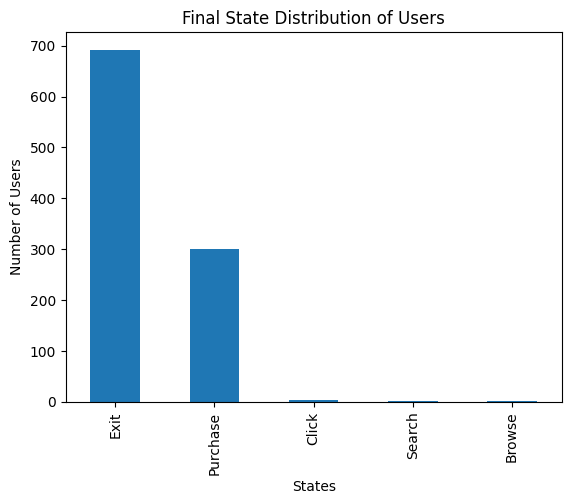

In [ ]:
state_counts.plot(kind='bar')

plt.title("Final State Distribution of Users")
plt.xlabel("States")
plt.ylabel("Number of Users")
plt.show()

In [ ]:
adaptive_matrix = transition_matrix.copy()

state_visit_counts = np.zeros(len(states))

learning_rate = 0.01

probability_history = []

for user in range(num_users):

    current_state = 0

    for step in range(num_steps):

        next_state = np.random.choice(
            range(len(states)),
            p=adaptive_matrix[current_state]
        )

        state_visit_counts[next_state] += 1

        adaptive_matrix[current_state][next_state] += learning_rate

        adaptive_matrix[current_state] /= adaptive_matrix[current_state].sum()

        probability_history.append(adaptive_matrix.copy())  # VERY IMPORTANT LINE

        current_state = next_state

print("Adaptive learning completed.")

Adaptive learning completed.


In [ ]:
adaptive_paths = []

for user in range(num_users):

    current_state = 0
    user_path = [states[current_state]]

    for step in range(num_steps):

        next_state = np.random.choice(
            range(len(states)),
            p=adaptive_matrix[current_state]
        )

        user_path.append(states[next_state])
        current_state = next_state

    adaptive_paths.append(user_path)


adaptive_final_states = [path[-1] for path in adaptive_paths]

adaptive_counts = pd.Series(adaptive_final_states).value_counts()

print(adaptive_counts)

Exit        632
Purchase    360
Click         6
Search        1
Browse        1
Name: count, dtype: int64


In [ ]:
comparison_df = pd.DataFrame({
    "Static Model": state_counts,
    "Adaptive Model": adaptive_counts
}).fillna(0)

comparison_df

,Static Model,Adaptive Model
Browse,1,0.0
Click,4,9.0
Exit,692,915.0
Purchase,301,76.0
Search,2,0.0


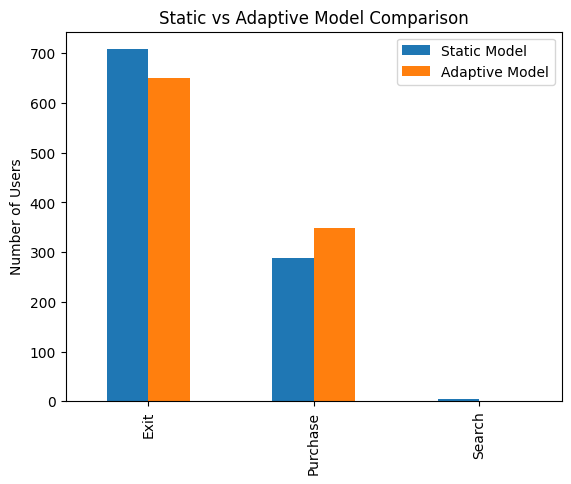

In [ ]:
comparison_df.plot(kind="bar")

plt.title("Static vs Adaptive Model Comparison")
plt.ylabel("Number of Users")

plt.savefig("comparison_plot.png")   # saves image file

plt.show()

10000


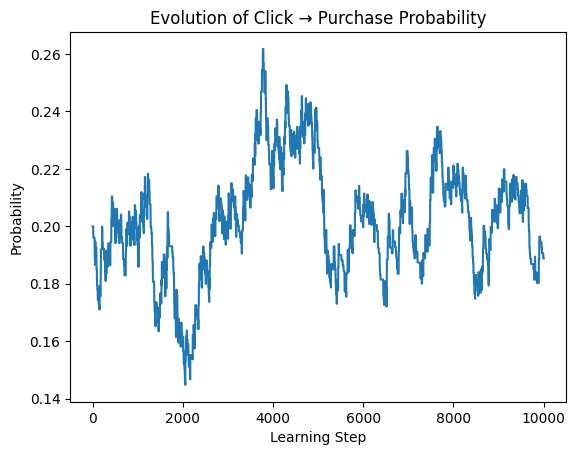

In [ ]:
click_to_purchase_history = []

for matrix in probability_history:
    click_to_purchase_history.append(matrix[2][3])

print(len(click_to_purchase_history))  # check values exist

plt.plot(click_to_purchase_history)

plt.title("Evolution of Click → Purchase Probability")
plt.xlabel("Learning Step")
plt.ylabel("Probability")

plt.savefig("probability_evolution.png")

plt.show()

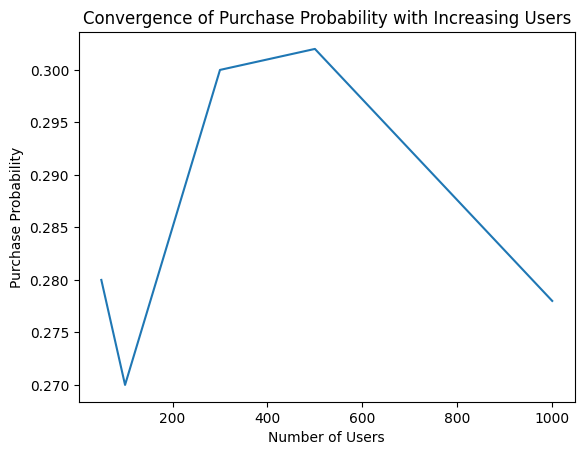

In [ ]:
user_sizes = [50, 100, 300, 500, 1000]
purchase_rates = []

for size in user_sizes:

    purchase_count = 0

    for user in range(size):

        current_state = 0

        for step in range(num_steps):

            next_state = np.random.choice(
                range(len(states)),
                p=transition_matrix[current_state]
            )

            current_state = next_state

        if states[current_state] == "Purchase":
            purchase_count += 1

    purchase_rates.append(purchase_count / size)


plt.plot(user_sizes, purchase_rates)

plt.title("Convergence of Purchase Probability with Increasing Users")
plt.xlabel("Number of Users")
plt.ylabel("Purchase Probability")

plt.savefig("convergence_plot.png")

plt.show()